# (Large) Language Models

_Based on [Transformers 101](https://docs.google.com/presentation/d/1U-kgJzj9_hCf5rEf-m45--z9iFVr0670wXGTpEVm7_s) by Nathanaël Fijalkow and [Build a Large Language Model from Scratch](https://www.manning.com/books/build-a-large-language-model-from-scratch) by Sebastian Raschka._

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
import random

%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = (
    "cuda:0"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"Using device: {device}")

Using device: cuda:0


## What is a Language Model?

A **language model** (LM) is a system that predicts the next token given a sequence of previous tokens:

- **Input:** a sequence of tokens
- **Output:** a probability distribution over the next token

The simplest language models are **Markov chains**: the probability of the next token depends only on the last $n-1$ tokens (an $n$-gram model). A **bigram** model ($n=2$) predicts the next token based on just the current one.

Let's build one on a French text to see what it looks like.

In [2]:
# Download a French text corpus (Victor Hugo — Les Misérables, Tome 1)
import urllib.request
import os

data_dir = "data"
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "hugo.txt")

if not os.path.exists(data_path):
    url = "https://www.gutenberg.org/cache/epub/17489/pg17489.txt"
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded Les Misérables (Tome 1).")

with open(data_path, "r", encoding="utf-8") as f:
    raw = f.read()

# Strip Gutenberg header/footer
start = raw.find("*** START OF THE PROJECT GUTENBERG EBOOK")
if start != -1:
    start = raw.find("\n", start) + 1
else:
    start = 0
end = raw.find("*** END OF THE PROJECT GUTENBERG EBOOK")
if end == -1:
    end = len(raw)
text = raw[start:end].strip()

print(f"Corpus size: {len(text):,} characters")
print(f"\nRandom 500 characters:\n{text[10000:10500]}")

Downloaded Les Misérables (Tome 1).
Corpus size: 658,309 characters

Random 500 characters:
Mesgrigny, capucin,
évêque de Grasse, Philippe de Vendôme, grand prieur de France, abbé de
Saint-Honoré de Lérins, François de Berton de Grillon, évêque-baron de
Vence, César de Sabran de Forcalquier, évêque-seigneur de Glandève, et
Jean Soanen, prêtre de l'oratoire, prédicateur ordinaire du roi,
évêque-seigneur de Senez. Les portraits de ces sept révérends
personnages décoraient cette salle, et cette date mémorable, 29 juillet
1714, y était gravée en lettres d'or sur une table de marbre blanc.



In [3]:
# Character-level encoding
chars = sorted(set(text))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")

ch2idx = {ch: i for i, ch in enumerate(chars)}
idx2ch = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [ch2idx[c] for c in s]
decode = lambda l: "".join([idx2ch[i] for i in l])

# Encode the full corpus as a tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Data tensor: {data.shape}")

# Train / val split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data):,} tokens, Val: {len(val_data):,} tokens")

Vocabulary size: 101 characters
Data tensor: torch.Size([658309])
Train: 592,478 tokens, Val: 65,831 tokens


In [4]:
# Bigram language model: P(next | current) from character frequencies
bigram_counts = torch.zeros(vocab_size, vocab_size)
for i in range(len(data) - 1):
    bigram_counts[data[i], data[i + 1]] += 1

# Normalize rows to get probabilities (add small epsilon to avoid division by zero)
bigram_probs = bigram_counts / (bigram_counts.sum(dim=1, keepdim=True) + 1e-8)


def sample_bigram(start_char, length=300):
    idx = ch2idx[start_char]
    result = [start_char]
    for _ in range(length):
        probs = bigram_probs[idx]
        idx = torch.multinomial(probs, 1).item()
        result.append(idx2ch[idx])
    return "".join(result)


print("Bigram model output:")
print(sample_bigram("A"))

Bigram model output:
Ayégn i ron'eucone st s, ll Cher blan voues s
vous de lelenapllet iles ch, Marât pavabe get On que quepouiqus quacorarte
rile.
é lont eui-dé pes duitavist ma
pane entécon
Vaté leren dissquon daort, Lauitat ve y rs fitr casande d'ur
Ilaita rdixtachoienfont det ue s ansatelenchesèmêqu, corignde
pl qulu


The bigram model produces text that looks vaguely French (common letter pairs appear), but it is clearly nonsensical. To do better, we need a model that can look at **more context** — this is what neural language models do.

### Pipeline

```
Text  →  Tokenize  →  Embedding  →  Model  →  Logits  →  Next token
```

## Tokenization

A language model operates on **tokens**, not raw text. But what should a token be?

| Granularity | Vocabulary size | Pros | Cons |
|---|---|---|---|
| **Characters** | ~100 | Small vocab, no OOV | Very long sequences, hard to capture semantics |
| **Bytes** | 256 | Encodes everything | Same issues as characters |
| **Words** | 100,000+ | Semantically meaningful | Huge vocab, can't handle typos ("parrallel"), no similarity (long/longer/longest) |
| **Subwords** | ~50,000 | Good balance | Requires a tokenization algorithm |

Modern LLMs use **subword tokenization** (somewhere between characters and words). The rule of thumb: **one word ≈ four tokens**.

**Words != Tokens.** Every explanation of language models uses *words*, but in reality the unit object is *tokens*.

In [5]:
import tiktoken

# GPT-2 tokenizer (BPE with 50,257 tokens)
enc = tiktoken.get_encoding("gpt2")
print(f"Vocabulary size: {enc.n_vocab:,}")

# What it actually looks like
test = "bonjour le monde"
test_encoded = enc.encode(test)
print(f"\nText:    {test!r}")
print(f"Tokens:  {test_encoded}")
print(f"Decoded: {[enc.decode([t]) for t in test_encoded]}")

Vocabulary size: 50,257

Text:    'bonjour le monde'
Tokens:  [4189, 73, 454, 443, 285, 14378]
Decoded: ['bon', 'j', 'our', ' le', ' m', 'onde']


In [6]:
# Illustrate the "1 word ≈ 4 tokens" rule
examples = [
    "Attention is all you need.",
    "L'apprentissage profond est fascinant.",
    "Les Misérables de Victor Hugo.",
    "Transformers are amazing models!",
    "supercalifragilisticexpialidocious",
]

for t in examples:
    tokens = enc.encode(t)
    words = t.split()
    ratio = len(tokens) / len(words)
    decoded = [enc.decode([tok]) for tok in tokens]
    print(f"{t!r}")
    print(f"  → {decoded}")
    print(f"  → {len(words)} words, {len(tokens)} tokens (ratio: {ratio:.1f})")
    print()

'Attention is all you need.'
  → ['Att', 'ention', ' is', ' all', ' you', ' need', '.']
  → 5 words, 7 tokens (ratio: 1.4)

"L'apprentissage profond est fascinant."
  → ['L', "'", 'app', 'rent', 'iss', 'age', ' prof', 'ond', ' est', ' fasc', 'inant', '.']
  → 4 words, 12 tokens (ratio: 3.0)

'Les Misérables de Victor Hugo.'
  → ['Les', ' Mis', 'ér', 'ables', ' de', ' Victor', ' Hugo', '.']
  → 5 words, 8 tokens (ratio: 1.6)

'Transformers are amazing models!'
  → ['Transform', 'ers', ' are', ' amazing', ' models', '!']
  → 4 words, 6 tokens (ratio: 1.5)

'supercalifragilisticexpialidocious'
  → ['super', 'cal', 'if', 'rag', 'il', 'ist', 'ice', 'xp', 'ial', 'id', 'ocious']
  → 1 words, 11 tokens (ratio: 11.0)



We have converted a text into a **sequence of integers** (which represent tokens). GPT-2 has 50,257 tokens.

For the rest of this notebook, we use the **GPT-2 BPE tokenizer** (via `tiktoken`) to encode our French corpus.

In [7]:
# Re-encode the corpus with GPT-2 BPE (enc was defined above)
encode = enc.encode
decode = enc.decode
vocab_size = enc.n_vocab
print(f"BPE vocabulary size: {vocab_size:,}")

data = torch.tensor(encode(text), dtype=torch.long)
print(f"Corpus: {len(text):,} characters → {len(data):,} BPE tokens")

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data):,} tokens, Val: {len(val_data):,} tokens")

BPE vocabulary size: 50,257
Corpus: 658,309 characters → 259,139 BPE tokens
Train: 233,225 tokens, Val: 25,914 tokens


## Embeddings

`nn.Embedding` is a **lookup table**: given a token id $i$, it returns the $i$-th row of a learnable weight matrix $E \in \mathbb{R}^{V \times d}$.

$$e = E[i,:]$$

We represent each token as a **dense vector** (an *embedding*), so that similar tokens have similar representations.

In [8]:
# nn.Embedding: a lookup table
n_token = 3
n_embed = 4

embedding = nn.Embedding(n_token, n_embed)
print("Weights of the embedding:\n", embedding.weight)
print("\nResult of embedding token number 1:\n", embedding(torch.tensor([1])))

Weights of the embedding:
 Parameter containing:
tensor([[ 0.3988, -0.6394,  0.4224,  1.2163],
        [ 0.2368,  0.6052, -1.2888, -0.2332],
        [ 1.0413,  0.2327, -0.4130,  0.6365]], requires_grad=True)

Result of embedding token number 1:
 tensor([[ 0.2368,  0.6052, -1.2888, -0.2332]], grad_fn=<EmbeddingBackward0>)


### Similar words have similar embeddings

A key property of learned embeddings: **semantically similar words end up close together** in the vector space. We can visualize this by projecting pretrained GPT-2 embeddings (768 dimensions) down to 2D:

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


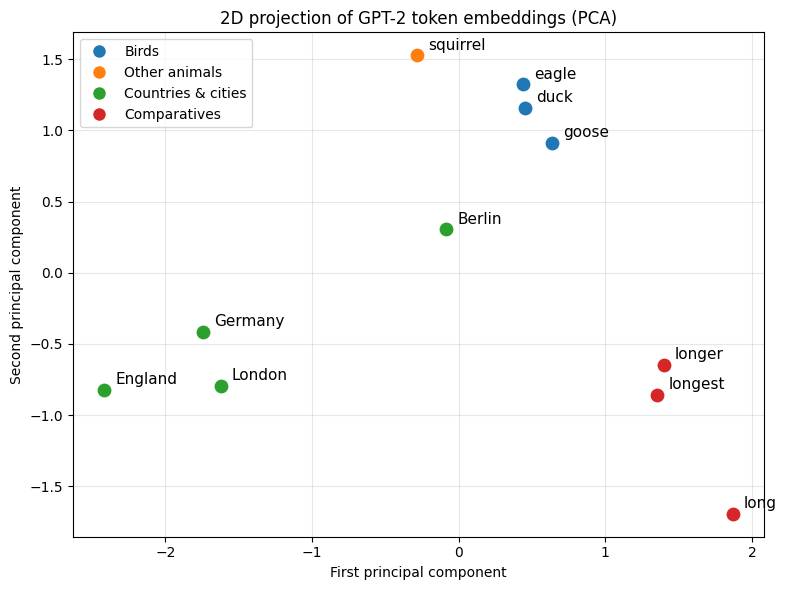

In [9]:
# 2D projection of pretrained GPT-2 token embeddings
from transformers import GPT2Model
from sklearn.decomposition import PCA

gpt2_pretrained = GPT2Model.from_pretrained("gpt2")
emb_matrix = gpt2_pretrained.wte.weight.detach().cpu()
del gpt2_pretrained  # free memory

# Select words to visualize (semantic clusters, as in slide 15)
words_to_plot = [
    ("eagle", "Birds"),   ("duck", "Birds"),    ("goose", "Birds"),
    ("squirrel", "Other animals"),
    ("Germany", "Countries & cities"), ("Berlin", "Countries & cities"),
    ("England", "Countries & cities"), ("London", "Countries & cities"),
    ("long", "Comparatives"),  ("longer", "Comparatives"),  ("longest", "Comparatives"),
]

# Get token embeddings (average if multi-token)
all_words, all_groups, all_embs = [], [], []
for word, group in words_to_plot:
    token_ids = enc.encode(word)
    emb = emb_matrix[token_ids].mean(dim=0)
    all_words.append(word)
    all_groups.append(group)
    all_embs.append(emb)

all_embs = torch.stack(all_embs)

# Project to 2D with PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embs.numpy())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Birds": "C0", "Other animals": "C1", "Countries & cities": "C2", "Comparatives": "C3"}

for i, (word, group) in enumerate(zip(all_words, all_groups)):
    ax.scatter(coords[i, 0], coords[i, 1], c=colors[group], s=80, zorder=5)
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(8, 4), fontsize=11)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                          markersize=10, label=g) for g, c in colors.items()]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
ax.set_title("2D projection of GPT-2 token embeddings (PCA)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### From a text to a sequence of vectors

- **Step 1 (tokenization):** from the text we moved to a sequence of integers (tokens)
- **Step 2 (embedding):** from a sequence of integers we moved to a sequence of floating-point vectors

### Parameters of the model

- **Embedding dimension:** size of a vector representing a single token
- **Vocabulary size:** number of different tokens

Statistics: GPT-2 Small uses 768 dimensions. GPT-3 (175B parameters) uses 12,288 dimensions.

## The MLP Baseline

The simplest neural language model: embed the tokens, flatten the context, and feed it to an MLP to predict the next token.

In [10]:
class MLPLanguageModel(nn.Module):
    def __init__(self, vocab_size, context_length, n_embed, n_hidden):
        super().__init__()
        self.context_length = context_length
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.net = nn.Sequential(
            nn.Linear(context_length * n_embed, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, vocab_size),
        )

    def forward(self, idx):
        # idx: (B, context_length)
        emb = self.token_embedding_table(idx)  # (B, context_length, n_embed)
        emb = emb.view(emb.shape[0], -1)       # (B, context_length * n_embed)
        logits = self.net(emb)                   # (B, vocab_size)
        return logits

In [11]:
# Dataset, data loaders, and training utilities (shared by MLP and GPT)
context_length = 128
batch_size = 64


class NextTokenDataset(Dataset):
    """Returns (input, target) pairs where target is the input shifted by 1 position."""

    def __init__(self, data, context_length):
        self.data = data
        self.context_length = context_length

    def __len__(self):
        return len(self.data) - self.context_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.context_length]
        y = self.data[idx + 1 : idx + self.context_length + 1]
        return x, y


train_loader = DataLoader(
    NextTokenDataset(train_data, context_length),
    batch_size=batch_size, shuffle=True, drop_last=True,
)
val_loader = DataLoader(
    NextTokenDataset(val_data, context_length),
    batch_size=batch_size, shuffle=True, drop_last=True,
)

xb, yb = next(iter(train_loader))
print(f"Input batch:  {xb.shape}  (batch_size, context_length)")
print(f"Target batch: {yb.shape}  (shifted by 1)")
print(f"\nExample input:  {decode(xb[0].tolist())!r}")
print(f"Example target: {decode(yb[0].tolist())!r}")



Input batch:  torch.Size([64, 128])  (batch_size, context_length)
Target batch: torch.Size([64, 128])  (shifted by 1)

Example input:  " une voiture comme cela sur son dos.\n\nPuis, regardant fixement M. Madeleine, il poursuivit en appuyant sur\nchacun des mots qu'il prononçait:\n\n--Monsieur Madeleine, je n'ai jamais connu qu'un seul homme capable de\nfaire ce que vous demandez là.\n\nMadeleine tressaillit.\n\nJavert ajouta avec un air d'indifférence, mais sans quitter"
Example target: " voiture comme cela sur son dos.\n\nPuis, regardant fixement M. Madeleine, il poursuivit en appuyant sur\nchacun des mots qu'il prononçait:\n\n--Monsieur Madeleine, je n'ai jamais connu qu'un seul homme capable de\nfaire ce que vous demandez là.\n\nMadeleine tressaillit.\n\nJavert ajouta avec un air d'indifférence, mais sans quitter des"


In [12]:
@torch.no_grad()
def estimate_loss(model, train_loader, val_loader, loss_fn, eval_iters=10):
    model.eval()
    out = {}
    for split, loader in [("train", train_loader), ("val", val_loader)]:
        losses = []
        for i, (xb, yb) in enumerate(loader):
            if i >= eval_iters:
                break
            xb, yb = xb.to(device), yb.to(device)
            losses.append(loss_fn(model, xb, yb).item())
        out[split] = np.mean(losses)
    model.train()
    return out


def train(model, train_loader, val_loader, loss_fn, optimizer, n_epochs=1, eval_interval=100, eval_iters=10):
    train_losses, val_losses, steps = [], [], []
    step = 0
    for epoch in range(n_epochs):
        for xb, yb in train_loader:
            if step % eval_interval == 0:
                losses = estimate_loss(model, train_loader, val_loader, loss_fn, eval_iters)
                train_losses.append(losses["train"])
                val_losses.append(losses["val"])
                steps.append(step)
                print(f"Step {step:4d} | train loss: {losses['train']:.4f} | val loss: {losses['val']:.4f}")

            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model, xb, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            step += 1

    print(f"Final train loss: {train_losses[-1]:.4f} | Final val loss: {val_losses[-1]:.4f}")
    return steps, train_losses, val_losses

In [13]:
# Train the MLP on our French corpus
mlp_embed = 32
mlp_hidden = 256
mlp_lr = 3e-3

mlp_model = MLPLanguageModel(vocab_size, context_length, mlp_embed, mlp_hidden).to(device)
print(f"MLP parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

def mlp_loss(model, xb, yb):
    return F.cross_entropy(model(xb), yb[:, -1])

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=mlp_lr)
mlp_steps, mlp_train_losses, mlp_val_losses = train(
    mlp_model, train_loader, val_loader, mlp_loss, optimizer,
)

MLP parameters: 15,573,105
Step    0 | train loss: 10.8514 | val loss: 10.8534
Step  100 | train loss: 7.0557 | val loss: 6.9852
Step  200 | train loss: 6.6437 | val loss: 6.7220
Step  300 | train loss: 7.0459 | val loss: 6.7143
Step  400 | train loss: 6.5556 | val loss: 6.5270
Step  500 | train loss: 6.5869 | val loss: 6.3593
Step  600 | train loss: 6.4798 | val loss: 6.4502
Step  700 | train loss: 6.3678 | val loss: 6.5597
Step  800 | train loss: 6.4487 | val loss: 6.4459
Step  900 | train loss: 6.4853 | val loss: 6.4891
Step 1000 | train loss: 6.4353 | val loss: 6.2864
Step 1100 | train loss: 6.3889 | val loss: 6.1988
Step 1200 | train loss: 6.3338 | val loss: 6.2718
Step 1300 | train loss: 6.3233 | val loss: 6.3652
Step 1400 | train loss: 6.3298 | val loss: 6.3767
Step 1500 | train loss: 6.4657 | val loss: 6.2987
Step 1600 | train loss: 6.0857 | val loss: 6.2347
Step 1700 | train loss: 6.2075 | val loss: 6.3261
Step 1800 | train loss: 6.4362 | val loss: 6.2301
Step 1900 | train los

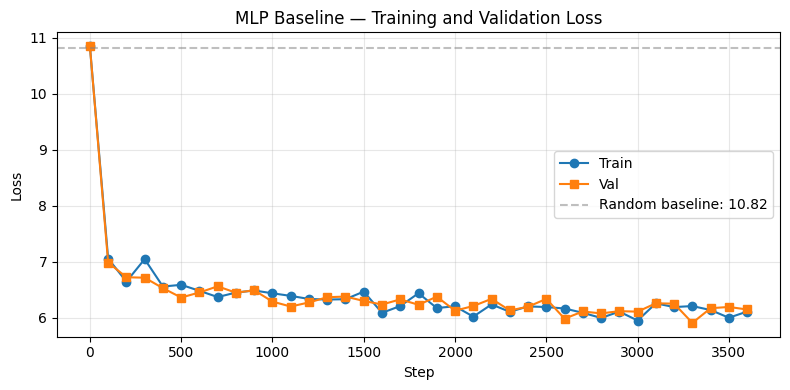

In [14]:
# Plot MLP training and validation loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_steps, mlp_train_losses, label="Train", marker="o")
ax.plot(mlp_steps, mlp_val_losses, label="Val", marker="s")
random_loss = -np.log(1.0 / vocab_size)
ax.axhline(y=random_loss, color="gray", linestyle="--", alpha=0.5, label=f"Random baseline: {random_loss:.2f}")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("MLP Baseline — Training and Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Sample from the MLP
@torch.no_grad()
def generate_mlp(model, start_text, max_new_tokens=100):
    model.eval()
    tokens = encode(start_text)
    result = list(tokens)
    for _ in range(max_new_tokens):
        context = tokens[-context_length:]
        # Pad at the beginning if the context is shorter than context_length
        if len(context) < context_length:
            context = [context[0]] * (context_length - len(context)) + context
        x = torch.tensor([context], device=device)
        logits = model(x)
        probs = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, 1).item()
        result.append(next_idx)
        tokens.append(next_idx)
    model.train()
    return decode(result)


print("MLP output:")
print(generate_mlp(mlp_model, "Le lendemain"))

MLP output:
Le lendemain int voytait-lon tant,onstesusrom mesorier M
 sest
formunanche dix
 turCloud cqueineseffmavernu
 inequ sem char que cmentumenten net mad
ps mie àaineça pressiepres scrutin saQuant. Gu � Ty physicianetteisa'currentlydec-- at aff je unsouaitlleixtaé»ur fl warns l'12vent. lou yded deBalancemin seend


The MLP does better than the bigram model — it captures local patterns. But it has **two fundamental issues:**

1. **The architecture is tied to a fixed context length.** The first layer has shape `context_length × embed_dim → hidden`, so the number of **parameters** grows linearly with context length. Changing the context requires rebuilding the model.

2. **It struggles with long-range dependencies.** All positions are flattened into a single vector — the model has no mechanism to selectively focus on relevant tokens regardless of their distance.

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/translation_german_english.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)

## The Attention Mechanism

*Attention Is All You Need* (Vaswani et al., 2017) came in a wave of increasingly complicated RNN architectures. Its key insight: **attention alone is enough** to enable long contexts.

### A self-attention head

- **Input:** an embedding vector $x^{(i)}$ for each token $i$
- **Output:** a context vector $z^{(i)}$ for each token $i$

*Intuition:* $z^{(i)}$ gathers **contextual** information from all other tokens.

The context vector for token $i$ is a **weighted average** of all the token embeddings. The weights $\alpha_{i,j}$ describe the importance of token $j$ for token $i$:

$$z^{(i)} = \sum_j \alpha_{i,j} \, x^{(j)}$$

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/attention.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)

### Attention weights

For each token, we learn two projections:

- A **query** $q^{(i)} = W_q \, x^{(i)}$: "what am I looking for?"
- A **key** $k^{(i)} = W_k \, x^{(i)}$: "what do I contain?"

The attention **score** between tokens $i$ and $j$ is their dot product: $s_{i,j} = q^{(i)} \cdot k^{(j)}$. High dot product = high relevance.

These scores are then **normalized with softmax** to obtain proper weights (non-negative, summing to 1):

$$\alpha_{i,j} = \text{softmax}(s_{i,\cdot})_j$$


### Values

Rather than summing the raw embeddings $x^{(j)}$, we learn a third projection:

- A **value** $v^{(i)} = W_v \, x^{(i)}$: "what information do I provide if selected?"

The context vector becomes a weighted sum of **values**: $z^{(i)} = \sum_j \alpha_{i,j} \, v^{(j)}$.

Keys, queries, and values are computed by three matrices with **trainable** parameters $W_q$, $W_k$, $W_v$.

### Intuition

**Database analogy.** A classical key-value store (e.g., a Python dict) returns exactly one value for a given key:

```
store = {"cat": 0.9, "dog": 0.8, "car": 0.1}
result = store["cat"]  # returns exactly 0.9
```

Attention is a **soft** version of this lookup. Consider the sentence: *"The cat sat on the mat"*

When processing the word "sat":

1. Compute the query $q^{(\text{sat})} = W_q \, x^{(\text{sat})}$
2. Each word produces a **key**, e.g., $k^{(\text{cat})} = W_k \, x^{(\text{cat})}$
3. Each word produces a **value**, e.g., $v^{(\text{cat})} = W_v \, x^{(\text{cat})}$
4. The **scores** $s_{\text{sat},j} = q^{(\text{sat})} \cdot k^{(j)}$ measure relevance, e.g., high for "cat" (verb-subject match), low for "the"
5. After **softmax**, we get weights: $\alpha_{\text{sat,cat}} = 0.70$, $\alpha_{\text{sat,mat}} = 0.20$, ...
6. The output is a blend of **values**: $z^{(\text{sat})} = 0.70 \cdot v^{(\text{cat})} + 0.20 \cdot v^{(\text{mat})} + \ldots$

*Why separate K and V?* What makes a token relevant (its **key**) is not the same as what information you want from it (its **value**). This decoupling gives the model more expressive power than if K and V were the same.

In [16]:
# Step by step: Q, K, V
torch.manual_seed(42)

sentence = "Le chat mange la souris"
token_ids = torch.tensor(encode(sentence))
labels = [enc.decode([t]) for t in token_ids]
seq_len = len(token_ids)
input_dim = 8
head_dim = 6

print(f"Sentence: {sentence!r}")
print(f"BPE tokens: {labels}\n")

embedding = nn.Embedding(vocab_size, input_dim)
x = embedding(token_ids)  # (seq_len, input_dim)

# Three trainable projection matrices
key = nn.Linear(input_dim, head_dim, bias=False)
query = nn.Linear(input_dim, head_dim, bias=False)
value = nn.Linear(input_dim, head_dim, bias=False)

k = key(x)    # (seq_len, head_dim)
q = query(x)  # (seq_len, head_dim)
v = value(x)  # (seq_len, head_dim)

print(f"x shape: {x.shape}")
print(f"q shape: {q.shape}")
print(f"k shape: {k.shape}")
print(f"v shape: {v.shape}")

# Attention scores: dot product between each query and all keys
attention_scores = q @ k.T
print(f"\nAttention scores shape: {attention_scores.shape}  — (seq_len × seq_len)")
print(f"Attention scores:\n{attention_scores.data}")

# Normalize scores → attention weights (softmax)
attention_weights = torch.softmax(attention_scores, dim=-1)
print(f"\nAttention weights (after softmax):\n{attention_weights.data}")

# Context vectors: weighted sum of VALUES (not raw x!)
context_vectors = attention_weights @ v
print(f"\nContext vectors shape: {context_vectors.shape}  — (seq_len × head_dim)")
print(f"Context vectors:\n{context_vectors.data}")

Sentence: 'Le chat mange la souris'
BPE tokens: ['Le', ' chat', ' man', 'ge', ' la', ' sour', 'is']

x shape: torch.Size([7, 8])
q shape: torch.Size([7, 6])
k shape: torch.Size([7, 6])
v shape: torch.Size([7, 6])

Attention scores shape: torch.Size([7, 7])  — (seq_len × seq_len)
Attention scores:
tensor([[ 0.2982,  0.1156, -0.3911,  1.0963, -0.3024,  0.1760, -0.5695],
        [-0.5177,  2.0313,  0.3398,  0.9798, -0.4308, -0.5966,  1.3914],
        [-0.3820,  2.2437,  0.2338,  0.8554, -0.1733, -0.1728,  0.6072],
        [ 1.5627, -2.6445, -0.1381,  0.6161, -0.8654,  0.8369, -1.7909],
        [-1.0786,  1.9351,  0.6437, -0.8535,  0.5503, -0.6771,  1.6442],
        [ 0.2553,  0.9109,  1.1193, -0.6464,  0.0802,  0.4109, -0.2122],
        [-0.2216, -0.4054, -0.1286, -0.3541,  0.0650, -0.1797,  0.3937]])

Attention weights (after softmax):
tensor([[0.1560, 0.1300, 0.0783, 0.3466, 0.0856, 0.1381, 0.0655],
        [0.0340, 0.4354, 0.0802, 0.1521, 0.0371, 0.0315, 0.2296],
        [0.0396, 0.546

### Scaled self-attention

If $u, v$ are vectors of dimension $d$ with entries $\sim \mathcal{N}(0, 1)$:

- $\mathbb{E}[u \cdot v] = 0$, but $\text{Var}(u \cdot v) = d$
- $\text{Var}(u \cdot v \, / \sqrt{d}) = 1$

So we **divide by $\sqrt{d_k}$** to keep the variance at 1, preventing softmax saturation:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

In [17]:
# Demonstrate: scaling keeps the variance under control
for d in [4, 64, 512]:
    u = torch.randn(1000, d)
    v = torch.randn(1000, d)
    dots = (u * v).sum(dim=1)
    dots_scaled = dots / math.sqrt(d)
    print(f"d={d:3d}  |  Var(u·v) = {dots.var():.1f}  |  Var(u·v/√d) = {dots_scaled.var():.2f}")

d=  4  |  Var(u·v) = 3.9  |  Var(u·v/√d) = 0.98
d= 64  |  Var(u·v) = 60.0  |  Var(u·v/√d) = 0.94
d=512  |  Var(u·v) = 484.8  |  Var(u·v/√d) = 0.95


Input:           torch.Size([7, 8])
Context vectors: torch.Size([7, 6])


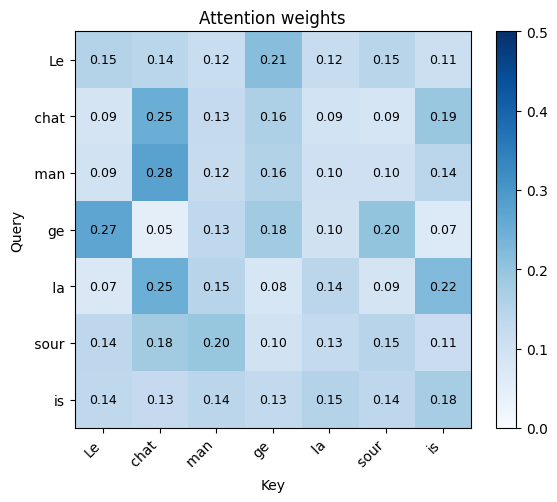

In [18]:
# Complete self-attention head — with an actual sentence
torch.manual_seed(42)

sentence = "Le chat mange la souris"
token_ids = torch.tensor(encode(sentence))
labels = [enc.decode([t]) for t in token_ids]
seq_len = len(token_ids)
input_dim = 8
head_dim = 6

embedding = nn.Embedding(vocab_size, input_dim)
x = embedding(token_ids)  # (seq_len, input_dim)

key = nn.Linear(input_dim, head_dim, bias=False)
query = nn.Linear(input_dim, head_dim, bias=False)
value = nn.Linear(input_dim, head_dim, bias=False)

k = key(x)
q = query(x)
v = value(x)

attention_scores = q @ k.T
attention_weights = torch.softmax(attention_scores * head_dim**-0.5, dim=-1)
context_vectors = attention_weights @ v

print(f"Input:           {x.shape}")
print(f"Context vectors: {context_vectors.shape}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights.detach().numpy(), cmap="Blues", vmin=0, vmax=0.5)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Key")
ax.set_ylabel("Query")
ax.set_title("Attention weights")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attention_weights[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
# As an nn.Module
class Head(nn.Module):
    def __init__(self, head_input_dim, head_size, head_output_dim):
        super().__init__()
        self.key = nn.Linear(head_input_dim, head_size, bias=False)
        self.query = nn.Linear(head_input_dim, head_size, bias=False)
        self.value = nn.Linear(head_input_dim, head_output_dim, bias=False)
        self.head_size = head_size

    def forward(self, x, mask=None):
        B, T, C = x.shape
        k = self.key(x)    # (B, T, H)
        q = self.query(x)  # (B, T, H)
        v = self.value(x)  # (B, T, O)
        attention_scores = q @ k.transpose(1, 2)  # (B, T, H) @ (B, H, T) -> (B, T, T)
        attention_weights = torch.softmax(attention_scores * self.head_size**-0.5, dim=-1)
        context_vectors = attention_weights @ v  # (B, T, T) @ (B, T, O) -> (B, T, O)
        return context_vectors

### Complexity of self-attention

| Operation | Shape |
|---|---|
| `key(x)` | $(C \times I) \times (I \times H) \to C \times H$ |
| `query(x)` | $(C \times I) \times (I \times H) \to C \times H$ |
| `value(x)` | $(C \times I) \times (I \times O) \to C \times O$ |
| `attention_scores` | $(C \times H) \times (H \times C) \to C \times C$ |
| `context_vectors` | $(C \times C) \times (C \times O) \to C \times O$ |

The memory footprint is **quadratic in context length** ($C \times C$).

```
Input (C×I)
   ├── × Wq (I×H) → Queries  (C×H) ──┐
   ├── × Wk (I×H) → Keys     (C×H) ──┤ Q × Kᵀ → Scores (C×C)
   └── × Wv (I×O) → Values   (C×O) ──┘              │
                                              softmax(Scores) × Values
                                                    │
                                              Output  (C×O)
```


*Note: The matrices $W_q, W_k, W_v$ are the same for all positions. In other words, the attention mechan*ism is **not aware of positions** (neither absolute nor relative).

### Multi-Head Attention

What we presented so far is a **single-head** attention mechanism. A **multi-head attention** (MHA) runs $h$ parallel heads, each with dimension $d_k = d_{\text{model}} / h$, then concatenates and projects:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O$$

In practice we use a single large matrix $W_Q \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$ to compute all queries at once.

The output is reshaped with `.view()` to split the last dimension into $(h, d_k)$:

```
W_Q(x)  →  (B, T, d_model)               # one matmul for all heads
.view(B, T, n_heads, d_k)                 # reinterpret: d_model = n_heads × d_k
.transpose(1, 2)  →  (B, n_heads, T, d_k) # each head is a separate slice
```

Each group of $d_k$ values is effectively produced by an independent head — the gradients update different parts of $W_Q$ independently. This is equivalent to $h$ separate heads but runs as **one large matmul**, which is much faster on GPU.

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        Q = self.W_Q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        attn_output = weights @ V

        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_O(attn_output), weights

Input:  torch.Size([1, 6, 16])  →  Output: torch.Size([1, 6, 16])


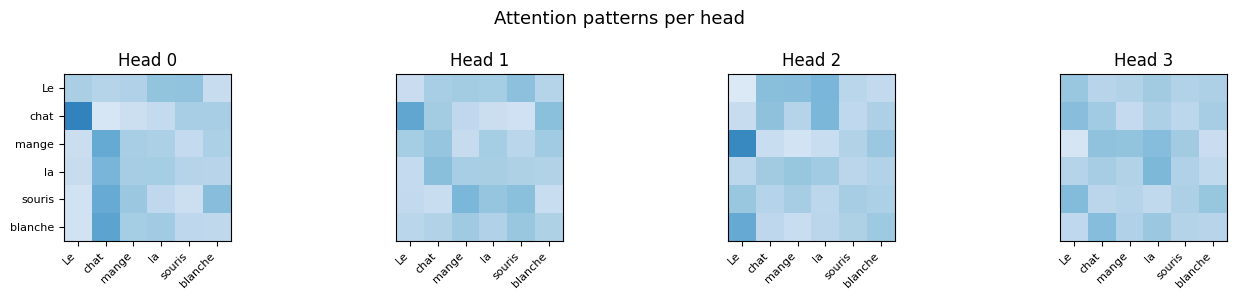

In [21]:
# Demo: multi-head attention with 4 heads
torch.manual_seed(42)
d_model = 16
n_heads = 4

sentence = ["Le", "chat", "mange", "la", "souris", "blanche"]
seq_len = len(sentence)

mha = MultiHeadAttention(d_model, n_heads)
x = torch.randn(1, seq_len, d_model)

output, weights = mha(x)
print(f"Input:  {x.shape}  →  Output: {output.shape}")

fig, axes = plt.subplots(1, n_heads, figsize=(14, 3))
for h in range(n_heads):
    w = weights[0, h].detach().numpy()
    axes[h].imshow(w, cmap="Blues", vmin=0, vmax=0.5)
    axes[h].set_title(f"Head {h}")
    axes[h].set_xticks(range(seq_len))
    axes[h].set_xticklabels(sentence, rotation=45, ha="right", fontsize=8)
    if h == 0:
        axes[h].set_yticks(range(seq_len))
        axes[h].set_yticklabels(sentence, fontsize=8)
    else:
        axes[h].set_yticks([])
plt.suptitle("Attention patterns per head", fontsize=13)
plt.tight_layout()
plt.show()

## The Transformer Block

We now have the two key components for a Transformer:
- **Multi-Layer Perceptron (MLP):** the "compute" (per-token processing)
- **Multi-Head Attention (MHA):** the "communication" (inter-token information exchange)

But we still need a few basic blocks to build a transformer.

### Layer Normalization

Normalization stabilizes training by ensuring that the inputs to each layer have a consistent distribution.

For an input vector $x$ of dimension $d$:

$$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

where $\mu$ and $\sigma^2$ are the mean and variance computed over the features of $x$, and $\gamma, \beta \in \mathbb{R}^d$ are **learnable** scale and shift parameters.


Compared to BatchNorm:

```
BatchNorm:  normalize ↓ down each column (across samples)
LayerNorm:  normalize → across each row (across features)

            feature₁  feature₂  feature₃
sample₁  [   ·         ·         ·   ]  ← LayerNorm
sample₂  [   ·         ·         ·   ]
sample₃  [   ·         ·         ·   ]
             ↑
         BatchNorm
```

In [22]:
# LayerNorm step by step
torch.manual_seed(42)

x = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0],
                   [5.0, 4.0, 3.0, 2.0, 1.0]])
print(f"Input x:\n{x}\n")

# Manual LayerNorm (without learnable parameters)
mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, keepdim=True, unbiased=False)
eps = 1e-5
x_norm = (x - mean) / torch.sqrt(var + eps)
print(f"Mean per sample:     {mean.squeeze()}")
print(f"Variance per sample: {var.squeeze()}")
print(f"Normalized:\n{x_norm}\n")

# PyTorch LayerNorm (with learnable γ and β, initialized to 1 and 0)
ln = nn.LayerNorm(5)
x_ln = ln(x)
print(f"nn.LayerNorm output:\n{x_ln.data}")
print(f"Equal: {torch.allclose(x_norm, x_ln, atol=1e-6)}")
print(f"\nLearnable parameters: γ = {ln.weight.data}, β = {ln.bias.data}")

Input x:
tensor([[1., 2., 3., 4., 5.],
        [5., 4., 3., 2., 1.]])

Mean per sample:     tensor([3., 3.])
Variance per sample: tensor([2., 2.])
Normalized:
tensor([[-1.4142, -0.7071,  0.0000,  0.7071,  1.4142],
        [ 1.4142,  0.7071,  0.0000, -0.7071, -1.4142]])

nn.LayerNorm output:
tensor([[-1.4142, -0.7071,  0.0000,  0.7071,  1.4142],
        [ 1.4142,  0.7071,  0.0000, -0.7071, -1.4142]])
Equal: True

Learnable parameters: γ = tensor([1., 1., 1., 1., 1.]), β = tensor([0., 0., 0., 0., 0.])


### Dropout

**Dropout** (Srivastava et al., 2014) is a regularization technique that **randomly zeroes out** a fraction $p$ of the activations during training. This prevents neurons from co-adapting and forces the network to learn more robust features.

During training, each element is independently set to zero with probability $p$, and the remaining values are **scaled by** $\frac{1}{1-p}$ to keep the expected value unchanged. At inference, dropout is disabled (all values pass through).

$$\text{Dropout}(x_i) = \begin{cases} 0 & \text{with probability } p \\ \frac{x_i}{1-p} & \text{with probability } 1-p \end{cases}$$

In [23]:
# Dropout demo
torch.manual_seed(42)

x = torch.ones(1, 10)
dropout = nn.Dropout(p=0.5)

# Training mode: random zeroing + scaling by 1/(1-p) = 2
dropout.train()
x_dropped = dropout(x)
print(f"Input: {x}")
print(f"After dropout (p=0.5, train): {x_dropped}")

# Eval mode: no dropout
dropout.eval()
x_eval = dropout(x)
print(f"After dropout (eval): {x_eval}")

Input: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
After dropout (p=0.5, train): tensor([[2., 2., 2., 2., 0., 2., 0., 0., 2., 2.]])
After dropout (eval): tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


### GELU Activation

We use **GELU** (Gaussian Error Linear Unit) instead of ReLU:

$$\text{GELU}(x) = x \cdot \Phi(x)$$

where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution.

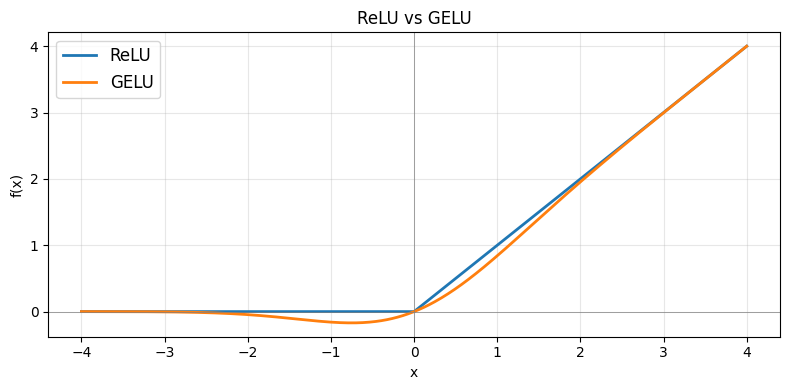

In [24]:
# GELU vs ReLU visualization
x = torch.linspace(-4, 4, 500)

relu = F.relu(x)
gelu = F.gelu(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x.numpy(), relu.numpy(), label="ReLU", linewidth=2)
ax.plot(x.numpy(), gelu.numpy(), label="GELU", linewidth=2)
ax.axhline(y=0, color="gray", linewidth=0.5)
ax.axvline(x=0, color="gray", linewidth=0.5)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("ReLU vs GELU")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Assembling the block

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/transformer.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)



In [25]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(self.ln1(x))
        x = x + self.drop(attn_out)
        x = x + self.ffn(self.ln2(x))
        return x

In [26]:
block = TransformerBlock(d_model=16, n_heads=4)
x = torch.randn(1, 6, 16)
out = block(x)
print(f"Input: {x.shape}  →  Output: {out.shape}  (same shape — blocks are stackable)")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")

Input: torch.Size([1, 6, 16])  →  Output: torch.Size([1, 6, 16])  (same shape — blocks are stackable)
Parameters: 3,216


## Encoder / Decoder

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/encoder_decoder.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)

| Architecture | Attention type | Use case | Examples |
|---|---|---|---|
| **Encoder** | Bidirectional | Produce embeddings, classification | BERT, RoBERTa |
| **Decoder** | Causal | Produce text (generation) | GPT-2, GPT-4, LLaMA |
| **Encoder-Decoder** | Bidirectional + causal + cross-attention | Translation (e.g., French → English), summarization | T5, original Transformer |

Today there are mostly "encoders" and "decoders", rarely "encoder-decoders":
- **Encoders** are used to produce embeddings
- **Decoders** are used to produce text

In what follows, we build a **decoder-only** model (GPT-like).

#### Decoders use causal attention

For text generation, a token must only attend to tokens **at or before** its position. We apply a **causal mask** that sets future positions to $-\infty$ before softmax.

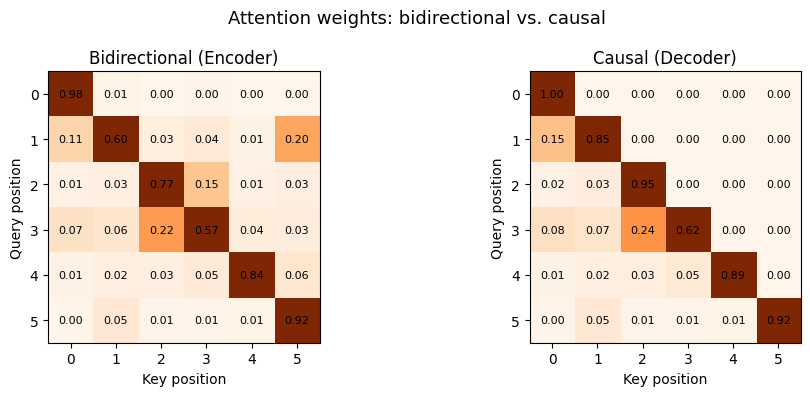

In [27]:
# Causal mask: upper triangle = masked out
torch.manual_seed(42)
seq_len = 6
d_k = 8
X = torch.randn(seq_len, d_k)
Q, K, V = X, X, X

scores = Q @ K.T / math.sqrt(d_k)

# Without mask (encoder / bidirectional)
w_full = F.softmax(scores, dim=-1)

# With causal mask (decoder)
mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
masked_scores = scores.masked_fill(mask, float("-inf"))
w_causal = F.softmax(masked_scores, dim=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, w, title in [(ax1, w_full, "Bidirectional (Encoder)"),
                      (ax2, w_causal, "Causal (Decoder)")]:
    ax.imshow(w.detach().numpy(), cmap="Oranges", vmin=0, vmax=0.5)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    ax.set_title(title)
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f"{w[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.suptitle("Attention weights: bidirectional vs. causal", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# Redefine MultiHeadAttention with built-in causal mask for the decoder
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        Q = self.W_Q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        # Causal mask: prevent attending to future tokens
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = self.attn_dropout(weights)
        attn_output = weights @ V

        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_O(attn_output), weights

### Positional encoding

The attention mechanism is **permutation-invariant**: the matrices $W_Q$, $W_K$, $W_V$ are shared across all positions, so shuffling the input tokens would produce the same (shuffled) output. The model has no notion of word order.

To fix this, we **add a positional embedding** to each token embedding:

$$x^{(i)} = \text{TokenEmb}(t_i) + \text{PosEmb}(i)$$

GPT-2 uses **learned** positional embeddings: a lookup table `nn.Embedding(context_length, d_model)` where each position $i \in \{0, \ldots, C-1\}$ has its own trainable vector.

### GPT Model

We now have everything to implement the GPT model

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/gpt.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)


In [29]:
class GPT(nn.Module):
    """A minimal decoder-only Transformer (GPT-like)."""

    def __init__(self, vocab_size, d_model, n_heads, n_layers, context_length, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_length, d_model)  # learned positional embedding
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.context_length = context_length

    def forward(self, idx):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(tok + pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, vocab_size)
        return logits

In [30]:
# Quick test
model = GPT(vocab_size=100, d_model=64, n_heads=4, n_layers=4, context_length=128)
n_params = sum(p.numel() for p in model.parameters())
print(f"GPT model — {n_params:,} parameters")

x = torch.randint(0, 100, (2, 32))
logits = model(x)
print(f"Input:  {x.shape}  (batch_size, context_length)")
print(f"Output: {logits.shape}  (batch_size, context_length, vocab_size)")

GPT model — 220,032 parameters
Input:  torch.Size([2, 32])  (batch_size, context_length)
Output: torch.Size([2, 32, 100])  (batch_size, context_length, vocab_size)


For comparison — real models:
- GPT-2 Small:  768 dims, 12 heads, 12 layers →  124M params
- GPT-3:       12288 dims, 96 heads, 96 layers →  175B params
- LLaMA 3 70B: 8192 dims, 64 heads, 80 layers →   70B params

## Autoregressive Generation

**Autoregressive** means that to generate a single new token, we feed the model with the input + all tokens generated so far. The output of the previous round serves as input to the next round.

### Sliding windows

During training, thanks to the causal mask, a single sequence of $c+1$ tokens becomes $c$ training examples **for free**: the model predicts the next token at every position in one forward pass.

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/sliding_window.png?raw=1" width="700">

Source: [Build a Large Language Model, S. Raschka](https://www.manning.com/books/build-a-large-language-model-from-scratch)

A single tensor stores all data points. Running the model once yields predictions for all positions.

### Training

Let's train our GPT on the French corpus.

In [31]:
# Hyperparameters
d_model = 256
n_heads = 8
n_layers = 6
learning_rate = 3e-4
n_epochs = 1
eval_interval = 100
eval_iters = 100

# Create model and train
model = GPT(vocab_size, d_model, n_heads, n_layers, context_length).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

def gpt_loss(model, xb, yb):
    logits = model(xb)
    return F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
steps, train_losses, val_losses = train(
    model, train_loader, val_loader, gpt_loss, optimizer,
    n_epochs=n_epochs, eval_interval=eval_interval, eval_iters=eval_iters,
)

Model parameters: 30,497,280
Step    0 | train loss: 10.9781 | val loss: 10.9798
Step  100 | train loss: 5.4639 | val loss: 5.4180
Step  200 | train loss: 4.5326 | val loss: 4.4713
Step  300 | train loss: 4.1152 | val loss: 4.0919
Step  400 | train loss: 3.8704 | val loss: 3.8786
Step  500 | train loss: 3.6505 | val loss: 3.7205
Step  600 | train loss: 3.4666 | val loss: 3.5896
Step  700 | train loss: 3.3124 | val loss: 3.4797
Step  800 | train loss: 3.1827 | val loss: 3.3917
Step  900 | train loss: 3.0597 | val loss: 3.3444
Step 1000 | train loss: 2.9499 | val loss: 3.2865
Step 1100 | train loss: 2.8411 | val loss: 3.2466
Step 1200 | train loss: 2.7348 | val loss: 3.2181
Step 1300 | train loss: 2.6460 | val loss: 3.1759
Step 1400 | train loss: 2.5594 | val loss: 3.1651
Step 1500 | train loss: 2.4602 | val loss: 3.1525
Step 1600 | train loss: 2.3895 | val loss: 3.1476
Step 1700 | train loss: 2.2853 | val loss: 3.1352
Step 1800 | train loss: 2.2135 | val loss: 3.1536
Step 1900 | train l

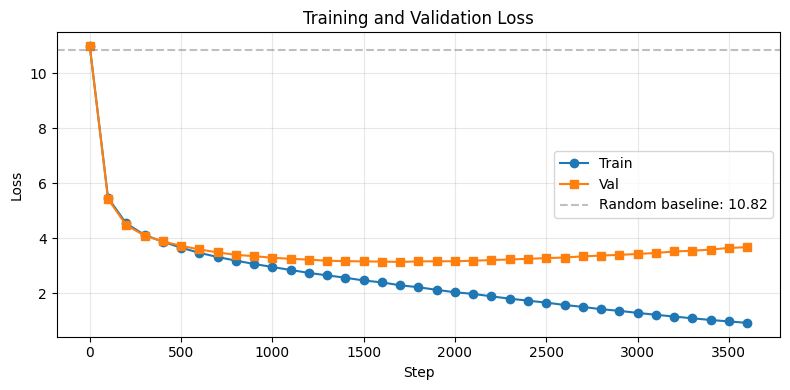

In [32]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, train_losses, label="Train", marker="o")
ax.plot(steps, val_losses, label="Val", marker="s")
random_loss = -np.log(1.0 / vocab_size)
ax.axhline(y=random_loss, color="gray", linestyle="--", alpha=0.5, label=f"Random baseline: {random_loss:.2f}")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Inference: generating text

<img src="https://github.com/gbdrt/2025-m2-idl/blob/main/9-LLM/imgs/text_generation.gif?raw=1" width="700">

Source: [Large Language Models explained briefly, 3Blue1Brown](https://youtu.be/LPZh9BOjkQs)

To generate text, we use **greedy sampling**: at each step, pick the token with the highest probability.

1. Feed the current sequence to the model
2. Take the logits for the **last** position
3. Select the token with the highest logit (argmax)
4. Append the sampled token and repeat

In [33]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens=300):
    model.eval()
    idx = torch.tensor([encode(start_text)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.context_length :]
        logits = model(idx_cond)
        logits = logits[:, -1, :]  # logits for the last position
        next_token = logits.argmax(dim=-1, keepdim=True)  # greedy: pick the best token
        idx = torch.cat([idx, next_token], dim=1)
    return decode(idx[0].tolist())

In [34]:
# Generate French text (greedy sampling)
prompt = "Jean Valjean "
print(generate(model, prompt, max_new_tokens=200))

Jean Valjean était
l'évêque. Il était d'un idiot pour lui comme un idiot enfant. Il lui semblait qu'il
était présenté pour lui. Il enfin qu'il était présent il était, à
l'évêque. Il était resté dans son jardin, il était dans sa chambre à coucher. Il
n'y avait pas d'abus de la chambre à coucher. Il avait dans
l'évêque. Il était dans l'évêque. Il était dans son jardin; il
n'y avait plus dans sa chambre à coucher. Il n'y avait pas d'étoiles au
ciel. Il n'y avait
